In [31]:
#Import Libraries
import pandas as pd
import numpy as np

In [32]:
df_fe = pd.read_csv("../data/processed/cleaned.csv")

In [33]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  object 
 1   Age                       100000 non-null  float64
 2   Occupation                100000 non-null  object 
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     100000 non-null  float64
 5   Num_Bank_Accounts         100000 non-null  float64
 6   Num_Credit_Card           100000 non-null  float64
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  float64
 9   Type_of_Loan              100000 non-null  object 
 10  Delay_from_due_date       100000 non-null  float64
 11  Num_of_Delayed_Payment    100000 non-null  float64
 12  Changed_Credit_Limit      100000 non-null  float64
 13  Num_Credit_Inquiries      100000 non-null  fl

In [34]:
#Conversion of target variable
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

df_fe["Credit_Score"] = target_encoder.fit_transform(df_fe["Credit_Score"])

Mapping will be similar to:               
Good      → 0
Poor      → 1
Standard  → 2

In [35]:
print(target_encoder.classes_)

['Good' 'Poor' 'Standard']


Feature Creation (New Features) : to improve the model 

Ratio features (highest impact):Raw numbers mean little without context. 

Debt-to-income (DTI) — total_monthly_debt / gross_monthly_income. The single most predictive feature in most credit models. Anything above 43% is typically a hard cutoff for mortgage lending.


In [36]:
df_fe["Debt_to_Income"] = (
    df_fe["Outstanding_Debt"] /
    df_fe["Annual_Income"]
)

In [37]:
df_fe["EMI_Ratio"] = (
    df_fe["Total_EMI_per_month"] /
    df_fe["Monthly_Inhand_Salary"]
)

In [38]:
df_fe["Investment_Ratio"] = (
    df_fe["Amount_invested_monthly"] /
    df_fe["Monthly_Inhand_Salary"]
)

Savings rate proxy — (income - total_expenses) / income. Signals financial discipline.

In [39]:
df_fe["Savings_Ratio"] = (
    df_fe["Monthly_Balance"] /
    df_fe["Monthly_Inhand_Salary"]
)

In [40]:
df_fe["Loan_per_Account"] = (
    df_fe["Num_of_Loan"] /
    (df_fe["Num_Bank_Accounts"] + 1)  #Adding +1 avoids division by zero.
)

Encode categorical columns

In [41]:
cat_cols = df_fe.select_dtypes(include="object").columns

print(cat_cols)

Index(['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix',
       'Payment_of_Min_Amount', 'Payment_Behaviour'],
      dtype='object')


In [42]:
#Ordinal Encoding: For naturally ordered categories
credit_mix_map = {
    "Bad":0,
    "Standard":1,
    "Good":2
}

df_fe["Credit_Mix"] = df_fe["Credit_Mix"].map(credit_mix_map)

In [43]:
#Binary Encoding
payment_map = {
    "No":0,
    "Yes":1,
    "Unknown":2
}

df_fe["Payment_of_Min_Amount"] = df_fe["Payment_of_Min_Amount"].map(payment_map)

In [44]:
#OneHotEncoder
df_fe = pd.get_dummies(
    df_fe,
    columns=[
        "Month",
        "Occupation",
        "Payment_Behaviour"
    ],
    drop_first=True
)

In [45]:
#Dropping the "Type_of_Loan" column as it is not needed for modeling
df_fe.drop(columns=["Type_of_Loan"], inplace=True)

In [46]:
#check missing values
df_fe.isnull().sum()

Age                                                   0
Annual_Income                                         0
Monthly_Inhand_Salary                                 0
Num_Bank_Accounts                                     0
Num_Credit_Card                                       0
Interest_Rate                                         0
Num_of_Loan                                           0
Delay_from_due_date                                   0
Num_of_Delayed_Payment                                0
Changed_Credit_Limit                                  0
Num_Credit_Inquiries                                  0
Credit_Mix                                            0
Outstanding_Debt                                      0
Credit_Utilization_Ratio                              0
Credit_History_Age                                    0
Payment_of_Min_Amount                                 0
Total_EMI_per_month                                   0
Amount_invested_monthly                         

FEATURE SCALING: Algorithms like Logistic Regression and SVM benefit from scaling.

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [48]:
#Select numerical columns
num_cols = df_fe.select_dtypes(include=["int64","float64"]).columns

num_cols = num_cols.drop("Credit_Score")

In [49]:
df_fe[num_cols] = scaler.fit_transform(df_fe[num_cols])

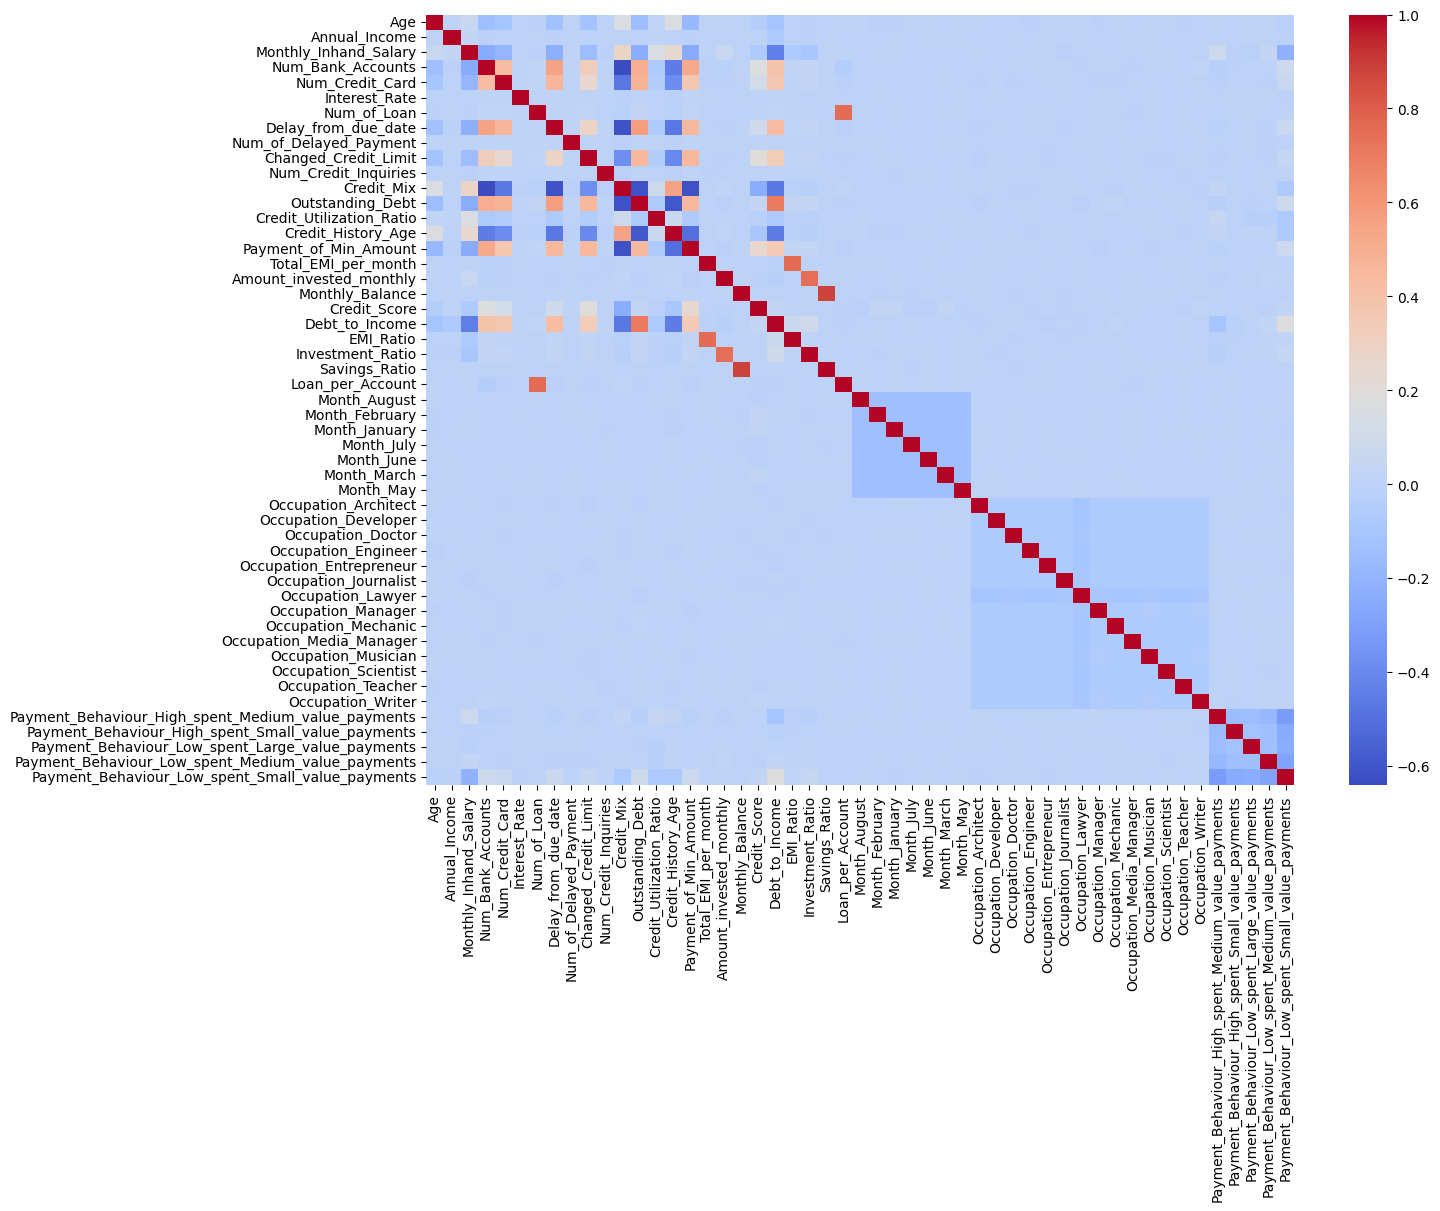

In [50]:
#Check correlation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    df_fe.corr(),
    cmap="coolwarm"
)

plt.show()

Heatmap indicates that feature engineering has been successful. Most features are not highly correlated with each other, which is desirable because it reduces multicollinearity and helps many machine learning algorithms generalize better. Most variables exhibit weak to moderate correlations, suggesting minimal multicollinearity. Financial variables such as annual income, monthly salary, outstanding debt, delay in payment, and credit utilization demonstrate meaningful relationships with one another, while the engineered features provide additional predictive information. The one-hot encoded categorical features are largely independent, making the dataset suitable for training classification models such as Logistic Regression, Decision Tree, Random Forest, and XGBoost.

FEATURE IMPORTANCE

In [51]:
from sklearn.ensemble import RandomForestClassifier

X = df_fe.drop("Credit_Score", axis=1)

y = df_fe["Credit_Score"]

rf = RandomForestClassifier(random_state=42)

rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [52]:
#importance
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                     Feature  Importance
12          Outstanding_Debt    0.093080
5              Interest_Rate    0.070741
7        Delay_from_due_date    0.054654
11                Credit_Mix    0.050837
19            Debt_to_Income    0.050207
9       Changed_Credit_Limit    0.049859
14        Credit_History_Age    0.048714
4            Num_Credit_Card    0.040091
10      Num_Credit_Inquiries    0.039505
1              Annual_Income    0.036822
13  Credit_Utilization_Ratio    0.036528
21          Investment_Ratio    0.035681
8     Num_of_Delayed_Payment    0.035564
17   Amount_invested_monthly    0.035054
20                 EMI_Ratio    0.034346
16       Total_EMI_per_month    0.032991
2      Monthly_Inhand_Salary    0.032722
3          Num_Bank_Accounts    0.030955
0                        Age    0.030473
23          Loan_per_Account    0.024249


The Random Forest feature importance analysis reveals that Outstanding_Debt is the most influential feature for predicting credit score, followed by Interest_Rate, Delay_from_due_date, Credit_Mix, and the engineered Debt_to_Income ratio. This demonstrates that debt obligations, repayment behavior, and credit history have a greater impact on creditworthiness than demographic factors such as age or income. Furthermore, the engineered financial ratio features enhanced the predictive capability of the model, confirming the value of domain-driven feature engineering.

In [53]:
#Save Final Dataset
df_fe.to_csv(
    "../data/processed/final_dataset.csv",
    index=False
)